In [1]:
# My dataset is on google drive so im mounting from google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Importing Depedencies and Tools

In [2]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Load Dataset

In [4]:
# Directories for training and testing data
train_dir = '/content/drive/MyDrive/MRI images/Training/'
test_dir = '/content/drive/MyDrive/MRI images/Testing/'

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

In [6]:
!pip install imagehash # install imagehash package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 56.2 MB/s eta 0:00:00


# For Duplicate files in Dataset


*   As i seen in dataset that there are alots of files are duplicated , which will impact model accuraccy and as well as go to overfitting


---



In [7]:
import imagehash

from PIL import Image

def find_duplicate_images(image_paths):
    hashes = {}
    duplicates = []
    for image_path in image_paths:
        try:
            image = Image.open(image_path)
            hash_value = imagehash.average_hash(image)  # hash algorithm

            if hash_value in hashes:
                duplicates.append((image_path, hashes[hash_value]))
            else:
                hashes[hash_value] = image_path
        except Exception as e:
            print(f"Error processing image {image_path}: {e}")
    return duplicates

# Find duplicates in training data
train_duplicates = find_duplicate_images(train_paths)
print("Duplicate images in training data:")
for duplicate in train_duplicates:
    print(duplicate)

# Find duplicates in testing data
test_duplicates = find_duplicate_images(test_paths)
print("\nDuplicate images in testing data:")
for duplicate in test_duplicates:
    print(duplicate) # Add this line to print the duplicates

Duplicate images in training data:
('/content/drive/MyDrive/MRI images/Training/pituitary/Tr-pi_1114.jpg', '/content/drive/MyDrive/MRI images/Training/meningioma/Tr-me_0290.jpg')
('/content/drive/MyDrive/MRI images/Training/pituitary/Tr-pi_0923.jpg', '/content/drive/MyDrive/MRI images/Training/meningioma/Tr-me_0290.jpg')
('/content/drive/MyDrive/MRI images/Training/notumor/Tr-no_1279.jpg', '/content/drive/MyDrive/MRI images/Training/notumor/Tr-no_0453.jpg')
('/content/drive/MyDrive/MRI images/Training/pituitary/Tr-pi_0945.jpg', '/content/drive/MyDrive/MRI images/Training/meningioma/Tr-me_0058.jpg')
('/content/drive/MyDrive/MRI images/Training/notumor/Tr-no_1547.jpg', '/content/drive/MyDrive/MRI images/Training/notumor/Tr-no_0795.jpg')
('/content/drive/MyDrive/MRI images/Training/glioma/Tr-gl_0161.jpg', '/content/drive/MyDrive/MRI images/Training/meningioma/Tr-me_0290.jpg')
('/content/drive/MyDrive/MRI images/Training/notumor/Tr-no_0998.jpg', '/content/drive/MyDrive/MRI images/Training/

In [8]:

import os

def remove_duplicate_images(duplicates, dry_run=True):
    for duplicate_pair in duplicates:
        image1_path, image2_path = duplicate_pair
        if dry_run:
          print(f"Would remove: {image2_path}")  # Indicate which file would be removed
        else:
          try:
              os.remove(image2_path)
              print(f"Removed: {image2_path}")
          except OSError as e:
              print(f"Error removing {image2_path}: {e}")


# Example usage (assuming train_duplicates and test_duplicates are defined as in your code):

# Remove duplicates from training data (dry run)
print("Removing duplicates from training data (dry run):")
remove_duplicate_images(train_duplicates)

# Remove duplicates from testing data (dry run)
print("\nRemoving duplicates from testing data (dry run):")
remove_duplicate_images(test_duplicates)

# To actually remove the files, set dry_run to False:
# remove_duplicate_images(train_duplicates, dry_run=False)
# remove_duplicate_images(test_duplicates, dry_run=False)


Removing duplicates from training data (dry run):
Would remove: /content/drive/MyDrive/MRI images/Training/meningioma/Tr-me_0290.jpg
Would remove: /content/drive/MyDrive/MRI images/Training/meningioma/Tr-me_0290.jpg
Would remove: /content/drive/MyDrive/MRI images/Training/notumor/Tr-no_0453.jpg
Would remove: /content/drive/MyDrive/MRI images/Training/meningioma/Tr-me_0058.jpg
Would remove: /content/drive/MyDrive/MRI images/Training/notumor/Tr-no_0795.jpg
Would remove: /content/drive/MyDrive/MRI images/Training/meningioma/Tr-me_0290.jpg
Would remove: /content/drive/MyDrive/MRI images/Training/notumor/Tr-no_0571.jpg
Would remove: /content/drive/MyDrive/MRI images/Training/meningioma/Tr-me_0290.jpg
Would remove: /content/drive/MyDrive/MRI images/Training/glioma/Tr-gl_1309.jpg
Would remove: /content/drive/MyDrive/MRI images/Training/notumor/Tr-no_0571.jpg
Would remove: /content/drive/MyDrive/MRI images/Training/meningioma/Tr-me_0016.jpg
Would remove: /content/drive/MyDrive/MRI images/Train

In [5]:
# Check how many files in dataset
print("Number of images in training folder:", len(train_paths))
print("Number of images in testing folder:", len(test_paths))

Number of images in training folder: 5505
Number of images in testing folder: 1281


# Data Visualizations

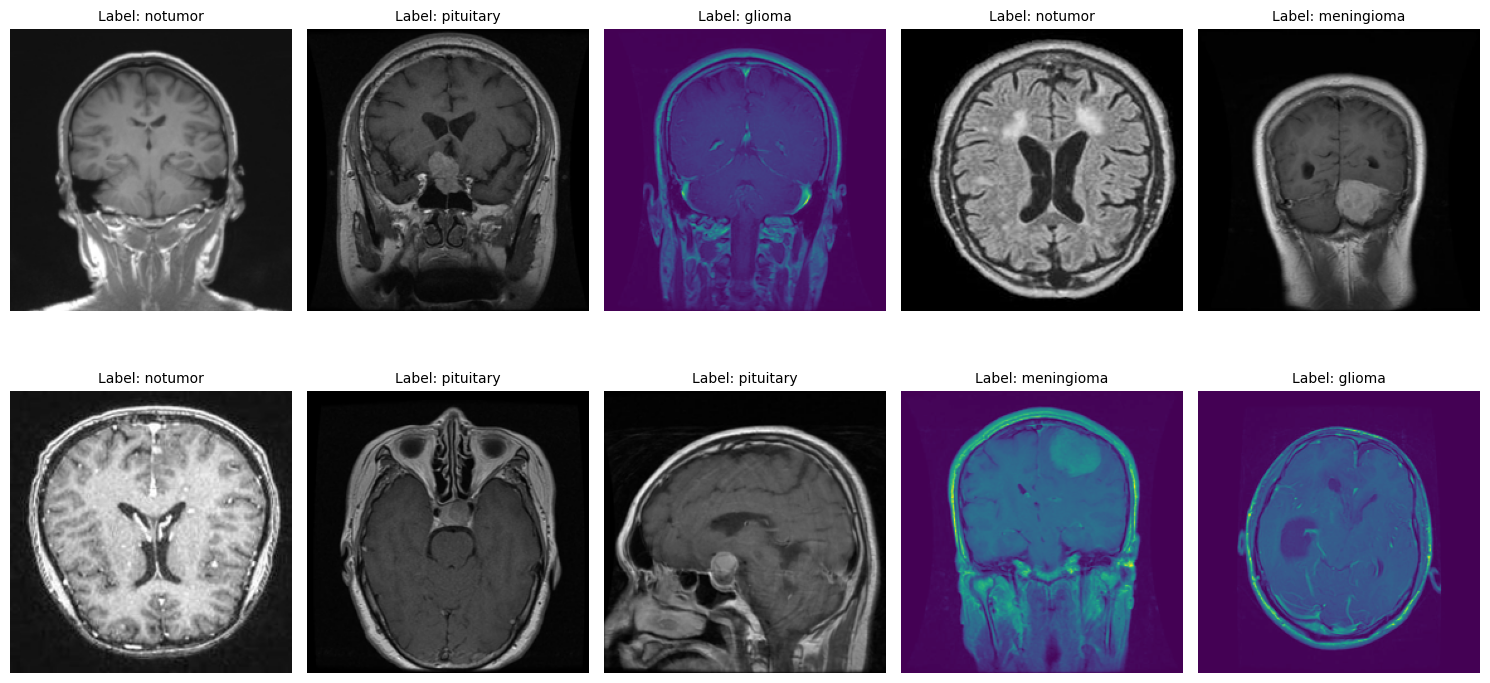

In [6]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize to consistent size

    # Display image
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide axis
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()


# Data Augmentation Proccess

In [7]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch


# Set up Early Stopping
early_stopping = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

# Set up Learning Rate Scheduler
reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.2, patience=3, min_lr=1e-6)

# Set up Model Checkpoint
checkpoint = ModelCheckpoint('best_model.keras', monitor='loss', save_best_only=True, mode='min', verbose=1)


# Model Architeecture

In [8]:
# Model architecture
IMAGE_SIZE = 128  # Image size (adjust based on your requirements)
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,048,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,763,908 (60.13 MB)

 Trainable params: 8,128,644 (31.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

# Compile model

In [9]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

In [10]:
# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 10

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps,callbacks=[early_stopping, reduce_lr, checkpoint])

Epoch 1/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 0.6498 - sparse_categorical_accuracy: 0.7368
Epoch 1: loss improved from inf to 0.44382, saving model to best_model.keras
275/275 ━━━━━━━━━━━━━━━━━━━━ 1757s 6s/step - loss: 0.6491 - sparse_categorical_accuracy: 0.7371 - learning_rate: 1.0000e-04
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.2744 - sparse_categorical_accuracy: 0.8985
Epoch 2: loss improved from 0.44382 to 0.24632, saving model to best_model.keras
275/275 ━━━━━━━━━━━━━━━━━━━━ 35s 109ms/step - loss: 0.2743 - sparse_categorical_accuracy: 0.8985 - learning_rate: 1.0000e-04
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.1718 - sparse_categorical_accuracy: 0.9348
Epoch 3: loss improved from 0.24632 to 0.16433, saving model to best_model.keras
275/275 ━━━━━━━━━━━━━━━━━━━━ 31s 112ms/step - loss: 0.1718 - sparse_categorical_accuracy: 0.9349 - learning_rate: 1.0000e-04
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.1232 

# Model evaluation

In [11]:
# Save the best model to Google Drive
model.save('/content/drive/MyDrive/best_model.keras')


In [22]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels_encoded, verbose=0)
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 0.9718969464302063


# Train and val plots

In [ ]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

# Classification reports

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))


41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       299
           1       0.99      1.00      1.00       381
           2       0.98      0.91      0.94       301
           3       0.97      1.00      0.98       300

    accuracy                           0.97      1281
   macro avg       0.97      0.97      0.97      1281
weighted avg       0.97      0.97      0.97      1281



# Confusion plot

Confusion Matrix:
[[292   0   5   2]
 [  0 381   0   0]
 [ 17   3 273   8]
 [  0   0   1 299]]


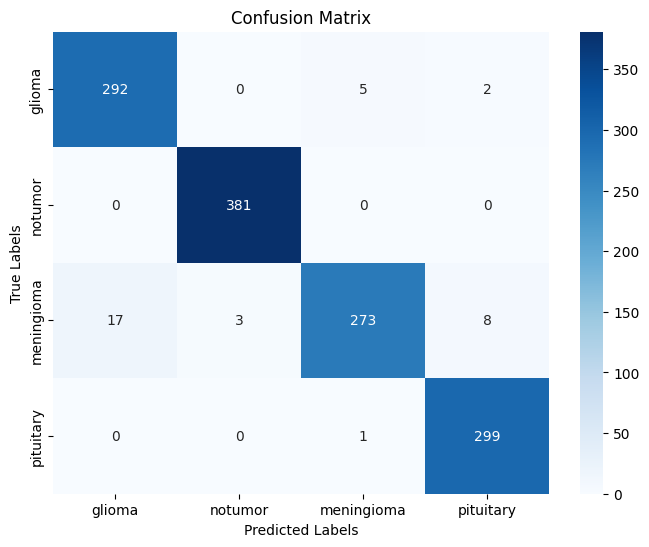

In [15]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Roc curve

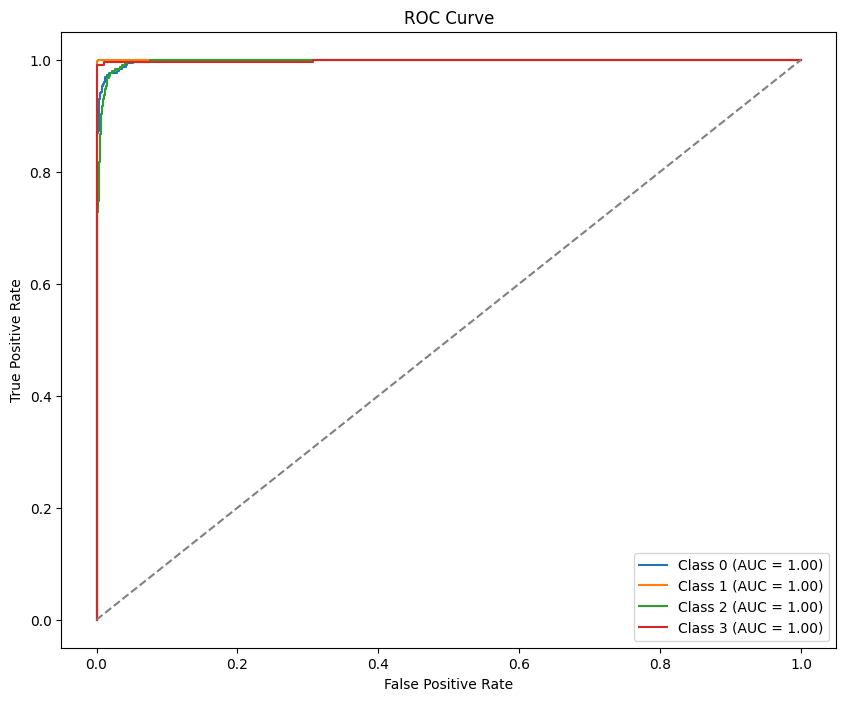

In [31]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [32]:
# Load the trained model
model = load_model('best_model.keras')

# Prediction System

In [43]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = ['glioma','notumor','meningioma','pituitary']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


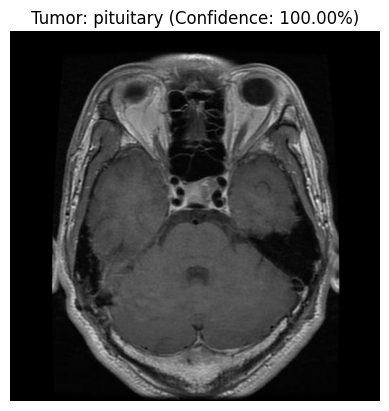

In [44]:
# Example usage
image_path = '/content/drive/MyDrive/MRI images/Testing/pituitary/Te-piTr_0000.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


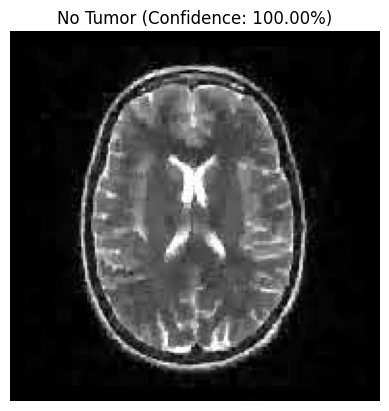

In [47]:

image_path = "/content/drive/MyDrive/MRI images/Testing/notumor/Te-no_0254.jpg" # Provide the path to your new image
detect_and_display(image_path, model)